# <span style ="color:red"> FRAUD DETECTION PREDICTION PROJECT </span>

In [45]:
#Import libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [5]:
# Loading the dataset using pandas
DATA_PATH = r"C:\Users\newuser123\Downloads\FdP\AIML Dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Number of rows: 6,362,620
Number of columns: 11


In [6]:
#Check the first rows of the dataset
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
#Check the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [8]:
#Check the column names of the dataset
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [9]:
#Check the number of columns and rows
df.shape

(6362620, 11)

In [10]:
#Check the statistical summary of the dataset
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [11]:
#Check the isFraud value in the dataset
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
#Check the isFlaggedFraud value in the dataset
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [13]:
#Check for null value in the dataset
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
#Checking the total value and percentage of fraud transactions in the dataset
fraud_count = df["isFraud"].value_counts().get(1, 0)
fraud_percentage = round((fraud_count / len(df)) * 100, 2)

print(f"Fraud transactions: {fraud_count}")
print(f"Fraud percentage: {fraud_percentage}%")

Fraud transactions: 8213
Fraud percentage: 0.13%


In [15]:
# Check missing values
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (
        missing_values.values / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

No missing values found.


In [16]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows:,}")

Number of duplicate rows: 0


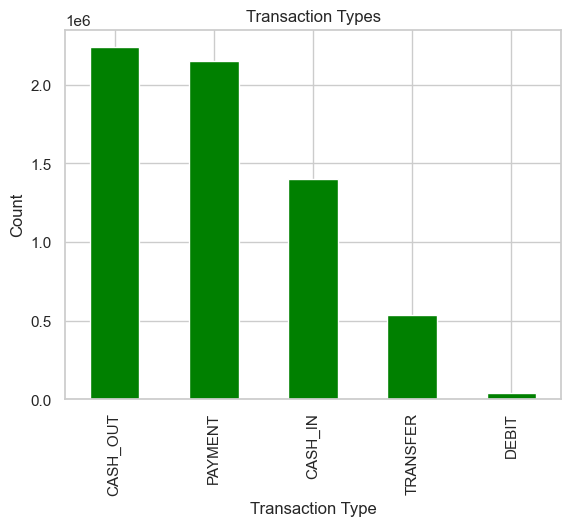

In [17]:
#Let analyse our data by visualizing our  transaction type
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color="green")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

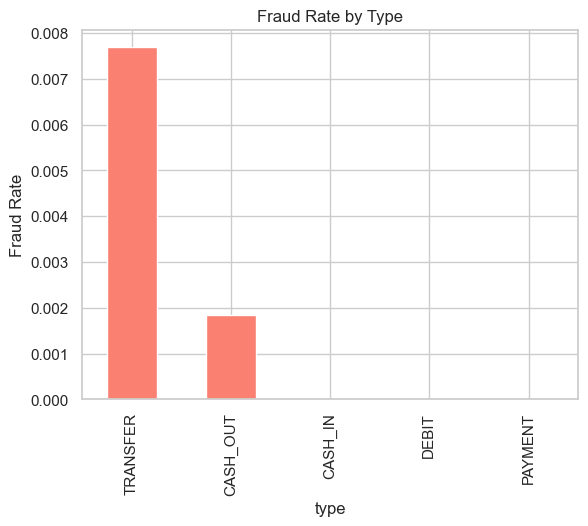

In [18]:
#Let find Fraud rate by Type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending =False)
fraud_by_type.plot(kind="bar", title ="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [19]:
#Check the fraud type to confirm our visualisation
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [20]:
#statistical summary check of the amount
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

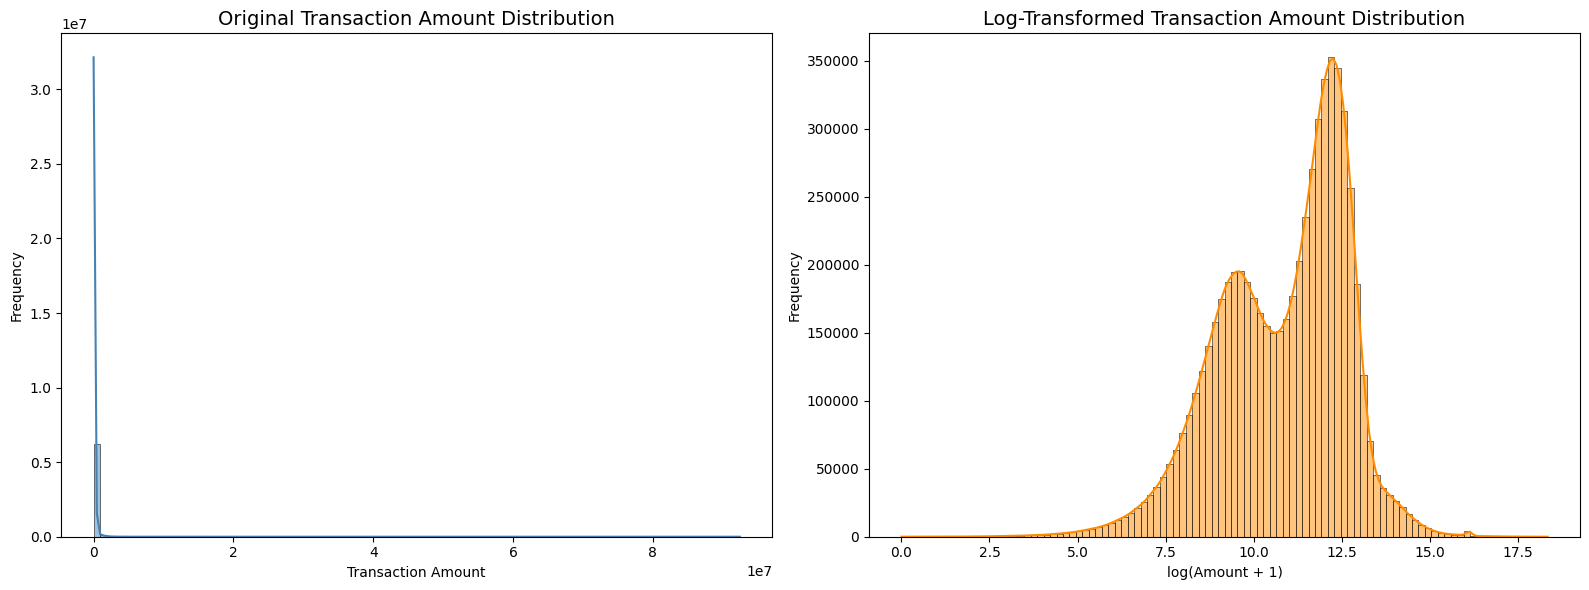

             Amount
count  6.362620e+06
mean   1.798619e+05
std    6.038582e+05
min    0.000000e+00
25%    1.338957e+04
50%    7.487194e+04
75%    2.087215e+05
max    9.244552e+07
Skewness Before Transformation: 30.99
Skewness After Transformation: -0.56


In [21]:
# Professional plotting style
plt.style.use("default")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Amount Distribution
sns.histplot(
    df["amount"],
    bins=100,
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Original Transaction Amount Distribution", fontsize=14)
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Frequency")

# Log-Transformed Distribution
sns.histplot(
    np.log1p(df["amount"]),
    bins=100,
    kde=True,
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Transaction Amount Distribution", fontsize=14)
axes[1].set_xlabel("log(Amount + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
summary = df["amount"].describe().to_frame()
summary.columns = ["Amount"]
print(summary)
print(f"Skewness Before Transformation: {df['amount'].skew():.2f}")

print(f"Skewness After Transformation: {np.log1p(df['amount']).skew():.2f}")

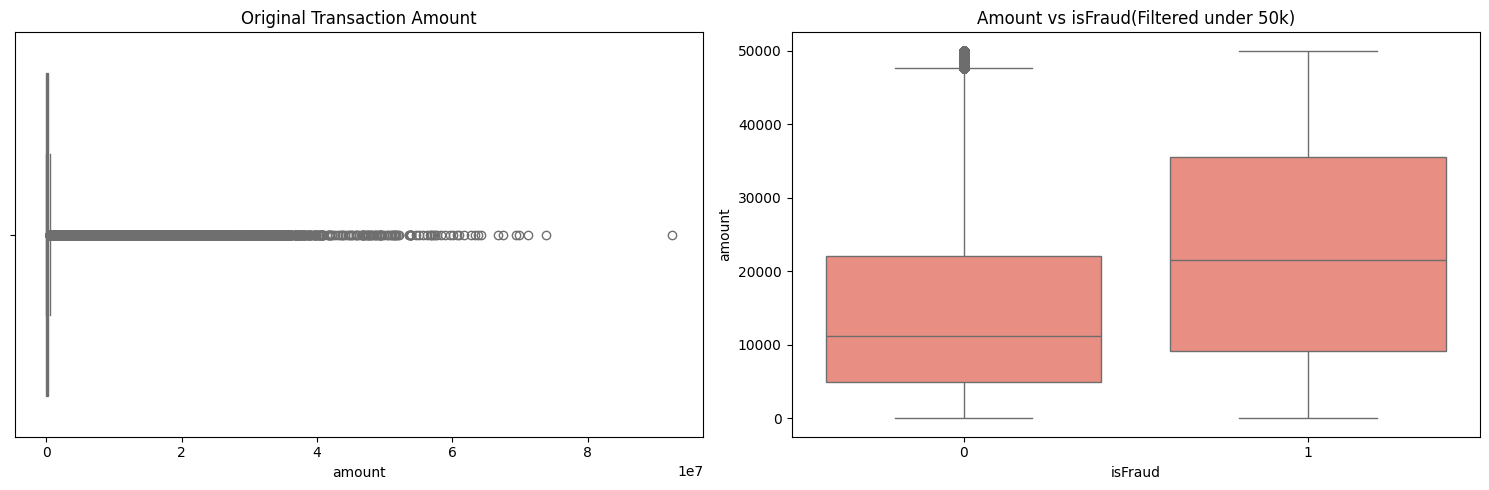

In [22]:
# Plotting Amount vs isFraud using a boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df["amount"], ax=axes[0], color="skyblue")
axes[0].set_title("Original Transaction Amount")

sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y="amount", color="salmon")
plt.title("Amount vs isFraud(Filtered under 50k)")

plt.tight_layout()
plt.show()

In [23]:
#Check balance chain and anomalies in the transaction
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceOrig"] - df["oldbalanceDest"]


In [24]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='str')

In [25]:
#check the balanceDiffOrig
(df["balanceDiffOrig"] <0).sum()

np.int64(1399253)

In [26]:
#check the balanceDiffDest
(df["balanceDiffDest"] <0).sum()

np.int64(2797585)

In [27]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,160296.36
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,19384.72


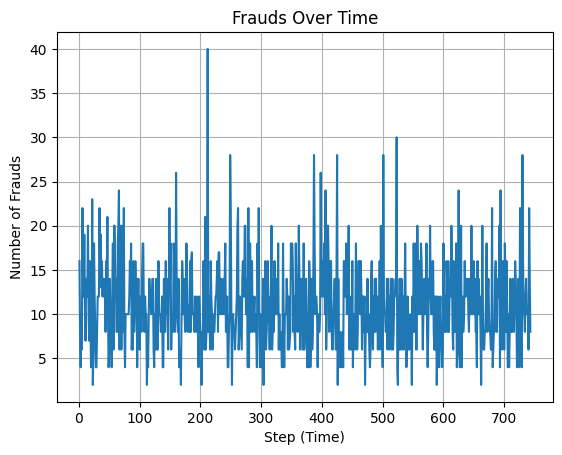

In [28]:
#Plot of Frauds over Time
frauds_per_step = df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [29]:
#Drop the columns step
df.drop(columns="step", inplace=True)

In [30]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,160296.36
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,19384.72
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.00
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,29885.86


In [31]:
#Customer with the top transaction
top_senders = df["nameOrig"].value_counts().head(10)

In [32]:
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [33]:
#Customer with the top receivers
top_recievers = df["nameDest"].value_counts().head(10)

In [34]:
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [35]:
#Customer that make fraud transaction or Fraud user customer
fraud_users = df[df["isFraud"]== 1] ["nameOrig"].value_counts().head(10)

In [36]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [37]:
#Fraud type analysis
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [38]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

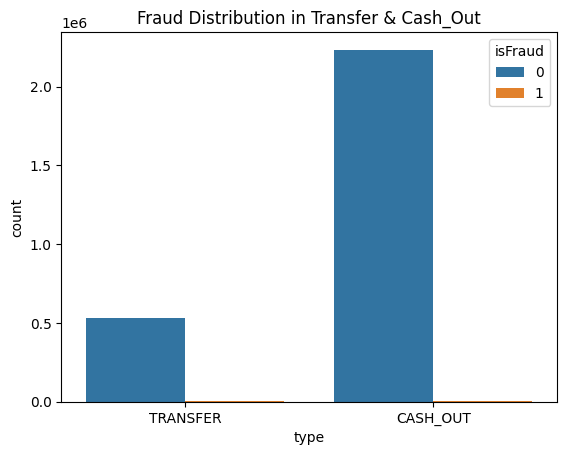

In [39]:
#Plot Fraud Distribution in Transfer and Cash_out Transaction in the datasets
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [40]:
#Correlation analysis
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [41]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


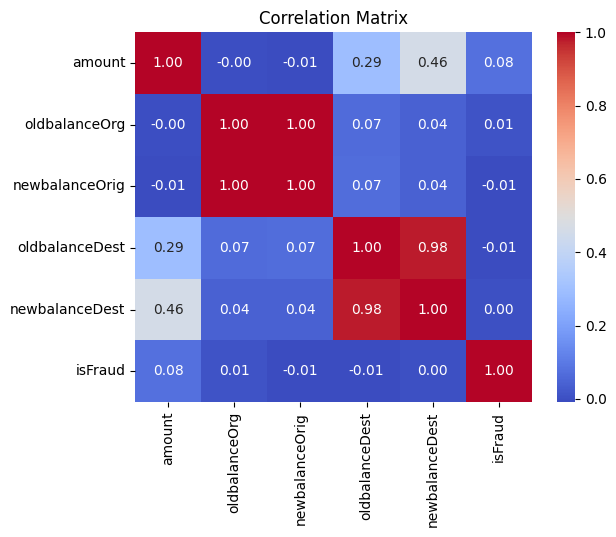

In [42]:
#Plot the correlation analysis using heatmap
sns.heatmap(corr,annot =True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [48]:
#Analyze the transfer after zero transfer
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
    ]

In [49]:
   len(zero_after_transfer)

1188074

In [54]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.0
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-5083.0
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.0
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-6267.0


In [55]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [56]:
#Feature Engineering Importing the libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [57]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,160296.36
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,19384.72
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.00
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,29885.86


In [58]:
#Drop some column that is not useful in our model
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)
print(f"nameOrig, nameDest and isFlaggedFraud drop successfully..")

nameOrig, nameDest and isFlaggedFraud drop successfully..


In [59]:
#Call the df_model to confirm if the column was drop
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,160296.36
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,19384.72
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.00
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.00
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,29885.86


In [60]:
#Set the Categorcal and numerical type
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
print(f"Categorical type and numeric successfully created")

Categorical type and numeric successfully created


In [62]:
#Target 
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)
print(f" Target successfully create..")

 Target successfully create..


In [72]:
#Train_test our model 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y )
print(f" train_test successfully..")

 train_test successfully..


In [73]:
#Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop ="first"), categorical)
    ],
    remainder ="drop"
)
print(f"Preprocessing successfully..")

Preprocessing successfully..


In [74]:
#Create a model Pipelines 
pipeline = Pipeline ([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

print(f"Pipeline model successful..")

Pipeline model successful..


In [75]:
#Train the model with the preprocessing
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [77]:
#Make prediction with our model
y_pred = pipeline.predict(X_test)
print(f"y_pred successful")

y_pred successful


In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [80]:
confusion_matrix(y_test, y_pred)

array([[1805537,  100785],
       [    157,    2307]])

In [82]:
#score of model
pipeline.score(X_test, y_test) * 100

94.7117172904663

In [83]:
#Export the pipeline
import joblib
joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']